In [1]:
# ---------------------------
# Step 1: Setup
# ---------------------------

# Import required libraries
import torch
import sentencepiece as spm
import numpy as np
import pandas as pd
import random
import os

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Detect device (CPU or GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:

# ---------------------------
# Step 2: Dataset Import + Normalization
# ---------------------------

# Clone repo and unzip dataset
!git clone https://github.com/amir9ume/urdu_ghazals_rekhta.git
!unzip -q /kaggle/working/urdu_ghazals_rekhta/dataset/dataset.zip -d /kaggle/working/urdu_ghazals_rekhta/dataset

import os
import unicodedata
import re
from itertools import zip_longest

# Dataset path (Kaggle)
BASE_DIR = "/kaggle/working/urdu_ghazals_rekhta/dataset/dataset"

# Output normalized corpus files
SRC_FILE = "/kaggle/working/urdu.txt"    # Urdu side
TGT_FILE = "/kaggle/working/roman.txt"   # Roman/English side

# --- Normalization functions ---
def is_letter(ch):
    return ch.isalpha()

def remove_inner_dots(s: str) -> str:
    if not s:
        return s
    out = []
    L = len(s)
    for i, ch in enumerate(s):
        if ch == '.':
            prev_is_letter = (i - 1 >= 0 and is_letter(s[i-1]))
            next_is_letter = (i + 1 < L and is_letter(s[i+1]))
            if prev_is_letter and next_is_letter:
                continue
            else:
                out.append(ch)
        else:
            out.append(ch)
    return "".join(out)

def normalize_english(text: str) -> str:
    if not text:
        return ""
    text = text.lower()
    text = unicodedata.normalize("NFKD", text)
    text = text.encode("ascii", "ignore").decode("ascii")
    text = remove_inner_dots(text)
    text = re.sub(r"[‘’'\"`]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalize_urdu(text: str) -> str:
    if not text:
        return ""
    text = unicodedata.normalize("NFC", text)
    cleaned_chars = []
    for c in text:
        cp = ord(c)
        if (0xFB50 <= cp <= 0xFDFF) or (0xFE70 <= cp <= 0xFEFF):
            continue
        cleaned_chars.append(c)
    text = "".join(cleaned_chars)
    text = text.replace("ؔ", "")
    text = remove_inner_dots(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# --- File processor ---
def process_pair_files(en_file_path, ur_file_path, src_out, tgt_out):
    with open(en_file_path, "r", encoding="utf-8", errors="replace") as enf, \
         open(ur_file_path, "r", encoding="utf-8", errors="replace") as urf:
        for en_line, ur_line in zip_longest(enf, urf, fillvalue=""):
            en_line = en_line.strip()
            ur_line = ur_line.strip()
            if en_line and ur_line:
                en_norm = normalize_english(en_line)
                ur_norm = normalize_urdu(ur_line)
                if en_norm and ur_norm:
                    tgt_out.write(en_norm + "\n")  # Roman side
                    src_out.write(ur_norm + "\n")  # Urdu side

# --- Main normalization driver ---
def main():
    poets = sorted([d for d in os.listdir(BASE_DIR) if os.path.isdir(os.path.join(BASE_DIR, d))])
    created = 0
    with open(SRC_FILE, "w", encoding="utf-8") as src_out, open(TGT_FILE, "w", encoding="utf-8") as tgt_out:
        for poet in poets:
            poet_path = os.path.join(BASE_DIR, poet)
            en_dir = os.path.join(poet_path, "en")
            ur_dir = os.path.join(poet_path, "ur")
            if os.path.isdir(en_dir) and os.path.isdir(ur_dir):
                en_files = sorted([f for f in os.listdir(en_dir)])
                ur_files = sorted([f for f in os.listdir(ur_dir)])
                for enf_name, urf_name in zip(en_files, ur_files):
                    enf_path = os.path.join(en_dir, enf_name)
                    urf_path = os.path.join(ur_dir, urf_name)
                    process_pair_files(enf_path, urf_path, src_out, tgt_out)
                    created += 1
    print(f"✅ Normalization complete. Created '{SRC_FILE}' and '{TGT_FILE}'. Processed {created} file pairs.")

if __name__ == "__main__":
    main()

# --- Preview first 5 pairs ---
for i, (ur, ro) in enumerate(zip(open(SRC_FILE), open(TGT_FILE))):
    print("UR:", ur.strip())
    print("RO:", ro.strip())
    print("-"*50)
    if i == 4:
        break


Cloning into 'urdu_ghazals_rekhta'...
remote: Enumerating objects: 112, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 112 (delta 7), reused 6 (delta 6), pack-reused 103 (from 1)
Receiving objects: 100% (112/112), 2.03 MiB | 11.70 MiB/s, done.
Resolving deltas: 100% (51/51), done.
✅ Normalization complete. Created '/kaggle/working/urdu.txt' and '/kaggle/working/roman.txt'. Processed 1314 file pairs.
UR: آنکھ سے دور نہ ہو دل سے اتر جائے گا
RO: aankh se duur na ho dil se utar jaega
--------------------------------------------------
UR: وقت کا کیا ہے گزرتا ہے گزر جائے گا
RO: vaqt ka kya hai guzarta hai guzar jaega
--------------------------------------------------
UR: اتنا مانوس نہ ہو خلوت غم سے اپنی
RO: itna manus na ho khalvat-e-gham se apni
--------------------------------------------------
UR: تو کبھی خود کو بھی دیکھے گا تو ڈر جائے گا
RO: tu kabhi khud ko bhi dekhega to dar jaega
------------------------------------------

In [3]:
import re
import pickle
from collections import defaultdict, Counter
from typing import List, Dict, Tuple, Set
import json

class UrduRomanBPE:
    def __init__(self, vocab_size: int = 10000):
        self.vocab_size = vocab_size
        self.urdu_vocab = {}
        self.roman_vocab = {}
        self.urdu_merges = []
        self.roman_merges = []
        self.urdu_word_freqs = defaultdict(int)
        self.roman_word_freqs = defaultdict(int)
        
        # Special tokens
        self.special_tokens = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
        
    def _get_word_tokens(self, word: str) -> List[str]:
        """Split word into characters with end-of-word marker"""
        return list(word) + ['</w>']
    
    def _get_pairs(self, word_tokens: List[str]) -> Set[Tuple[str, str]]:
        """Get all pairs of consecutive tokens in word"""
        pairs = set()
        prev_char = word_tokens[0]
        for char in word_tokens[1:]:
            pairs.add((prev_char, char))
            prev_char = char
        return pairs
    
    def _merge_vocab(self, pair: Tuple[str, str], word_freqs: Dict[List[str], int]) -> Dict[List[str], int]:
        """Merge the most frequent pair in vocabulary"""
        new_word_freqs = {}
        bigram = re.escape(' '.join(pair))
        p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
        
        for word_tokens in word_freqs:
            word_str = ' '.join(word_tokens)
            new_word_str = p.sub(''.join(pair), word_str)
            new_word_tokens = new_word_str.split()
            new_word_freqs[tuple(new_word_tokens)] = word_freqs[word_tokens]
        
        return new_word_freqs
    
    def _build_bpe(self, word_freqs: Dict[str, int], target_vocab_size: int) -> Tuple[Dict, List]:
        """Build BPE vocabulary and merges"""
        # Initialize vocabulary with character-level tokens
        vocab = set()
        word_token_freqs = {}
        
        for word, freq in word_freqs.items():
            word_tokens = self._get_word_tokens(word)
            word_token_freqs[tuple(word_tokens)] = freq
            for token in word_tokens:
                vocab.add(token)
        
        # Add special tokens
        for token in self.special_tokens:
            vocab.add(token)
        
        merges = []
        
        # Iteratively merge most frequent pairs
        while len(vocab) < target_vocab_size:
            # Get all pairs and their frequencies
            pairs = defaultdict(int)
            for word_tokens, freq in word_token_freqs.items():
                word_pairs = self._get_pairs(list(word_tokens))
                for pair in word_pairs:
                    pairs[pair] += freq
            
            if not pairs:
                break
            
            # Find most frequent pair
            best_pair = max(pairs, key=pairs.get)
            
            # Merge the pair
            word_token_freqs = self._merge_vocab(best_pair, word_token_freqs)
            merges.append(best_pair)
            vocab.add(''.join(best_pair))
        
        # Create vocabulary mapping
        vocab_dict = {token: idx for idx, token in enumerate(sorted(vocab))}
        
        return vocab_dict, merges
    
    def _preprocess_urdu_text(self, text: str) -> str:
        """Preprocess Urdu text"""
        # Remove extra whitespaces and normalize
        text = re.sub(r'\s+', ' ', text.strip())
        # Remove punctuation except for sentence boundaries
        text = re.sub(r'[۔؟!]', ' <EOS> ', text)
        text = re.sub(r'[،؍]', ' ', text)  # Remove commas and other punctuation
        return text.strip()
    
    def _preprocess_roman_text(self, text: str) -> str:
        """Preprocess Roman Urdu text"""
        # Convert to lowercase and remove extra whitespaces
        text = text.lower().strip()
        text = re.sub(r'\s+', ' ', text)
        # Handle punctuation
        text = re.sub(r'[.!?]', ' <EOS> ', text)
        text = re.sub(r'[,;:]', ' ', text)
        return text.strip()
    
    def load_data(self, urdu_file: str, roman_file: str):
        """Load and preprocess data from files"""
        print("Loading data...")
        
        try:
            with open(urdu_file, 'r', encoding='utf-8') as f:
                urdu_lines = f.readlines()
            
            with open(roman_file, 'r', encoding='utf-8') as f:
                roman_lines = f.readlines()
            
            print(f"Loaded {len(urdu_lines)} Urdu sentences and {len(roman_lines)} Roman sentences")
            
            # Process Urdu text
            for line in urdu_lines:
                line = self._preprocess_urdu_text(line)
                if line:
                    words = line.split()
                    for word in words:
                        if word not in self.special_tokens:
                            self.urdu_word_freqs[word] += 1
            
            # Process Roman text
            for line in roman_lines:
                line = self._preprocess_roman_text(line)
                if line:
                    words = line.split()
                    for word in words:
                        if word not in self.special_tokens:
                            self.roman_word_freqs[word] += 1
            
            print(f"Urdu vocabulary size: {len(self.urdu_word_freqs)}")
            print(f"Roman vocabulary size: {len(self.roman_word_freqs)}")
            
        except FileNotFoundError as e:
            print(f"Error: File not found - {e}")
            print("Please make sure the files exist at the specified paths.")
        except Exception as e:
            print(f"Error loading data: {e}")
    
    def train(self):
        """Train BPE models for both Urdu and Roman Urdu"""
        print("Training BPE models...")
        
        # Train Urdu BPE
        print("Training Urdu BPE...")
        self.urdu_vocab, self.urdu_merges = self._build_bpe(
            self.urdu_word_freqs, 
            self.vocab_size // 2
        )
        
        # Train Roman Urdu BPE
        print("Training Roman Urdu BPE...")
        self.roman_vocab, self.roman_merges = self._build_bpe(
            self.roman_word_freqs, 
            self.vocab_size // 2
        )
        
        print(f"Urdu BPE vocabulary size: {len(self.urdu_vocab)}")
        print(f"Roman BPE vocabulary size: {len(self.roman_vocab)}")
        print(f"Urdu merges: {len(self.urdu_merges)}")
        print(f"Roman merges: {len(self.roman_merges)}")
    
    def _apply_bpe(self, word: str, vocab: Dict, merges: List) -> List[str]:
        """Apply BPE encoding to a word"""
        if not word:
            return []
        
        word_tokens = self._get_word_tokens(word)
        
        if len(word_tokens) == 1:
            return word_tokens
        
        for merge in merges:
            if len(word_tokens) == 1:
                break
            
            new_word_tokens = []
            i = 0
            
            while i < len(word_tokens):
                if (i < len(word_tokens) - 1 and 
                    word_tokens[i] == merge[0] and 
                    word_tokens[i + 1] == merge[1]):
                    new_word_tokens.append(''.join(merge))
                    i += 2
                else:
                    new_word_tokens.append(word_tokens[i])
                    i += 1
            
            word_tokens = new_word_tokens
        
        return word_tokens
    
    def encode_urdu(self, text: str) -> List[int]:
        """Encode Urdu text using trained BPE"""
        text = self._preprocess_urdu_text(text)
        tokens = []
        
        for word in text.split():
            if word in self.special_tokens:
                tokens.append(self.urdu_vocab.get(word, self.urdu_vocab['<UNK>']))
            else:
                bpe_tokens = self._apply_bpe(word, self.urdu_vocab, self.urdu_merges)
                for token in bpe_tokens:
                    tokens.append(self.urdu_vocab.get(token, self.urdu_vocab['<UNK>']))
        
        return tokens
    
    def encode_roman(self, text: str) -> List[int]:
        """Encode Roman Urdu text using trained BPE"""
        text = self._preprocess_roman_text(text)
        tokens = []
        
        for word in text.split():
            if word in self.special_tokens:
                tokens.append(self.roman_vocab.get(word, self.roman_vocab['<UNK>']))
            else:
                bpe_tokens = self._apply_bpe(word, self.roman_vocab, self.roman_merges)
                for token in bpe_tokens:
                    tokens.append(self.roman_vocab.get(token, self.roman_vocab['<UNK>']))
        
        return tokens
    
    def decode_urdu(self, token_ids: List[int]) -> str:
        """Decode Urdu token IDs back to text"""
        id_to_token = {idx: token for token, idx in self.urdu_vocab.items()}
        tokens = [id_to_token.get(token_id, '<UNK>') for token_id in token_ids]
        
        # Merge tokens and remove end-of-word markers
        text = ''.join(tokens).replace('</w>', ' ')
        return text.strip()
    
    def decode_roman(self, token_ids: List[int]) -> str:
        """Decode Roman Urdu token IDs back to text"""
        id_to_token = {idx: token for token, idx in self.roman_vocab.items()}
        tokens = [id_to_token.get(token_id, '<UNK>') for token_id in token_ids]
        
        # Merge tokens and remove end-of-word markers
        text = ''.join(tokens).replace('</w>', ' ')
        return text.strip()
    
    def save_model(self, filepath: str):
        """Save trained BPE model"""
        model_data = {
            'urdu_vocab': self.urdu_vocab,
            'roman_vocab': self.roman_vocab,
            'urdu_merges': self.urdu_merges,
            'roman_merges': self.roman_merges,
            'vocab_size': self.vocab_size,
            'special_tokens': self.special_tokens
        }
        
        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)
        print(f"Model saved to {filepath}")
    
    def load_model(self, filepath: str):
        """Load trained BPE model"""
        with open(filepath, 'rb') as f:
            model_data = pickle.load(f)
        
        self.urdu_vocab = model_data['urdu_vocab']
        self.roman_vocab = model_data['roman_vocab']
        self.urdu_merges = model_data['urdu_merges']
        self.roman_merges = model_data['roman_merges']
        self.vocab_size = model_data['vocab_size']
        self.special_tokens = model_data['special_tokens']
        print(f"Model loaded from {filepath}")

# Usage example and training script
def main():
    # Initialize BPE with desired vocabulary size
    bpe = UrduRomanBPE(vocab_size=8000)
    
    # Load your data
    bpe.load_data('/kaggle/working/urdu.txt', '/kaggle/working/roman.txt')
    
    # Train BPE models
    bpe.train()
    
    # Save the trained model
    bpe.save_model('/kaggle/working/bpe_model.pkl')
    
    # Test with your example
    urdu_text = "تو کبھی خود کو بھی دیکھے گا تو ڈر جائے گا"
    roman_text = "tu kabhi khud ko bhi dekhega to dar jaega"
    
    print("\n=== Testing BPE Encoding ===")
    print(f"Original Urdu: {urdu_text}")
    urdu_encoded = bpe.encode_urdu(urdu_text)
    print(f"Urdu Encoded: {urdu_encoded}")
    urdu_decoded = bpe.decode_urdu(urdu_encoded)
    print(f"Urdu Decoded: {urdu_decoded}")
    
    print(f"\nOriginal Roman: {roman_text}")
    roman_encoded = bpe.encode_roman(roman_text)
    print(f"Roman Encoded: {roman_encoded}")
    roman_decoded = bpe.decode_roman(roman_encoded)
    print(f"Roman Decoded: {roman_decoded}")
    
    # Print some vocabulary statistics
    print(f"\n=== Vocabulary Statistics ===")
    print(f"Urdu vocabulary size: {len(bpe.urdu_vocab)}")
    print(f"Roman vocabulary size: {len(bpe.roman_vocab)}")
    
    # Show some example tokens
    print(f"\nSample Urdu tokens:")
    for i, (token, idx) in enumerate(list(bpe.urdu_vocab.items())[:10]):
        print(f"  {token}: {idx}")
    
    print(f"\nSample Roman tokens:")
    for i, (token, idx) in enumerate(list(bpe.roman_vocab.items())[:10]):
        print(f"  {token}: {idx}")

if __name__ == "__main__":
    main()

# Additional utility functions for integration with your BiLSTM model
class DataProcessor:
    def __init__(self, bpe_model: UrduRomanBPE):
        self.bpe = bpe_model
    
    def prepare_training_data(self, urdu_file: str, roman_file: str, max_len: int = 50):
        """Prepare tokenized data for BiLSTM training"""
        urdu_sequences = []
        roman_sequences = []
        
        with open(urdu_file, 'r', encoding='utf-8') as f:
            urdu_lines = f.readlines()
        
        with open(roman_file, 'r', encoding='utf-8') as f:
            roman_lines = f.readlines()
        
        for urdu_line, roman_line in zip(urdu_lines, roman_lines):
            # Encode sequences
            urdu_seq = self.bpe.encode_urdu(urdu_line.strip())
            roman_seq = self.bpe.encode_roman(roman_line.strip())
            
            # Add SOS and EOS tokens
            urdu_seq = [self.bpe.urdu_vocab['<SOS>']] + urdu_seq + [self.bpe.urdu_vocab['<EOS>']]
            roman_seq = [self.bpe.roman_vocab['<SOS>']] + roman_seq + [self.bpe.roman_vocab['<EOS>']]
            
            # Truncate or pad sequences
            if len(urdu_seq) <= max_len and len(roman_seq) <= max_len:
                # Pad sequences
                while len(urdu_seq) < max_len:
                    urdu_seq.append(self.bpe.urdu_vocab['<PAD>'])
                while len(roman_seq) < max_len:
                    roman_seq.append(self.bpe.roman_vocab['<PAD>'])
                
                urdu_sequences.append(urdu_seq)
                roman_sequences.append(roman_seq)
        
        return urdu_sequences, roman_sequences
    
    def get_vocab_sizes(self):
        """Get vocabulary sizes for model initialization"""
        return len(self.bpe.urdu_vocab), len(self.bpe.roman_vocab)

Loading data...
Loaded 21003 Urdu sentences and 21003 Roman sentences
Urdu vocabulary size: 10302
Roman vocabulary size: 16889
Training BPE models...
Training Urdu BPE...
Training Roman Urdu BPE...
Urdu BPE vocabulary size: 4000
Roman BPE vocabulary size: 4000
Urdu merges: 3943
Roman merges: 3968
Model saved to /kaggle/working/bpe_model.pkl

=== Testing BPE Encoding ===
Original Urdu: تو کبھی خود کو بھی دیکھے گا تو ڈر جائے گا
Urdu Encoded: [806, 3544, 1211, 3631, 644, 1414, 3730, 806, 3477, 883, 3730]
Urdu Decoded: تو کبھی خود کو بھی دیکھے گا تو ڈر جائے گا

Original Roman: tu kabhi khud ko bhi dekhega to dar jaega
Roman Encoded: [3634, 1698, 1906, 1978, 523, 793, 933, 3626, 750, 1551]
Roman Decoded: tu kabhi khud ko bhi dekhega to dar jaega

=== Vocabulary Statistics ===
Urdu vocabulary size: 4000
Roman vocabulary size: 4000

Sample Urdu tokens:
  ': 0
  </w>: 1
  <EOS>: 2
  <PAD>: 3
  <SOS>: 4
  <UNK>: 5
  ء: 6
  آ: 7
  آ</w>: 8
  آؤ</w>: 9

Sample Roman tokens:
  -: 0
  -ba-: 1
  -e-

Using device: cuda
STEP 1: Training BPE Model
Model loaded from /kaggle/working/bpe_model.pkl
Loaded existing BPE model

=== Testing BPE Encoding ===
Original Urdu: تو کبھی خود کو بھی دیکھے گا تو ڈر جائے گا
Urdu Encoded: [806, 3544, 1211, 3631, 644, 1414, 3730, 806, 3477, 883, 3730]
Urdu Decoded: تو کبھی خود کو بھی دیکھے گا تو ڈر جائے گا

Original Roman: tu kabhi khud ko bhi dekhega to dar jaega
Roman Encoded: [3634, 1698, 1906, 1978, 523, 793, 933, 3626, 750, 1551]
Roman Decoded: tu kabhi khud ko bhi dekhega to dar jaega

STEP 2: Preparing Training Data
Prepared 21003 sequence pairs
Training samples: 14702
Validation samples: 6301

STEP 3: Creating and Training Model
Encoder vocab size: 4000
Decoder vocab size: 4000
Model created with 30,250,912 total parameters
Trainable parameters: 30,250,912
Starting training for 10 epochs...


Epoch 1: 100%|██████████| 460/460 [03:12<00:00,  2.39it/s, Loss=1.1336]


Epoch 1/10:
  Train Loss: 1.3977
  Val Loss: 1.4141
  Val BLEU: 0.0000
  Val PPL: 4.11
  Val CER: 0.0000
  Learning Rate: 0.001000
  New best model saved!


Epoch 2: 100%|██████████| 460/460 [03:11<00:00,  2.40it/s, Loss=0.8959]


Epoch 2/10:
  Train Loss: 1.1414
  Val Loss: 1.2052
  Val BLEU: 0.0000
  Val PPL: 3.34
  Val CER: 0.0000
  Learning Rate: 0.001000
  New best model saved!


...

Epoch 8/10:
  Train Loss: 0.3795
  Val Loss: 0.7552
  Val BLEU: 0.0000
  Val PPL: 2.13
  Val CER: 0.0000
  Learning Rate: 0.001000


Epoch 9: 100%|██████████| 460/460 [03:10<00:00,  2.42it/s, Loss=0.4293]


Epoch 9/10:
  Train Loss: 0.3499
  Val Loss: 0.6706
  Val BLEU: 0.0000
  Val PPL: 1.96
  Val CER: 0.0000
  Learning Rate: 0.001000
  New best model saved!


Epoch 10: 100%|██████████| 460/460 [03:10<00:00,  2.42it/s, Loss=0.3742]


Epoch 10/10:
  Train Loss: 0.3172
  Val Loss: 0.6452
  Val BLEU: 0.0000
  Val PPL: 1.91
  Val CER: 0.0000
  Learning Rate: 0.001000
  New best model saved!
Training completed!


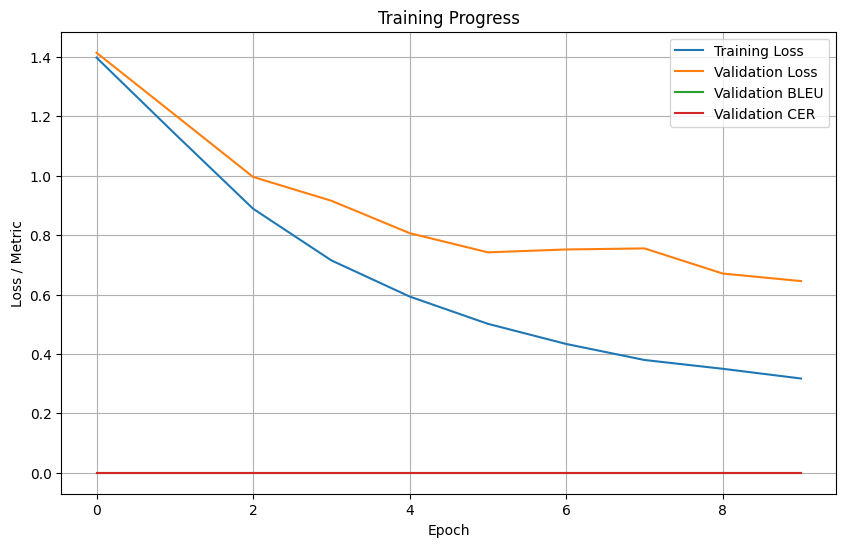


STEP 4: Testing Translation
Input Urdu: تو کبھی خود کو بھی دیکھے گا تو ڈر جائے گا
Translated Roman: to kabhi khud ko bhi dekhe yega to jaega jaega jaega jaega
Expected Roman: tu kabhi khud ko bhi dekhega to dar jaega

Model info saved to /kaggle/working/model_info.pkl
Training pipeline completed successfully!


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import random
import pickle
from typing import List, Tuple, Optional, Dict, Set
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from collections import defaultdict, Counter
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Try to import editdistance, install if not available
try:
    import editdistance
except ImportError:
    print("Installing editdistance package...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "editdistance"])
    import editdistance

# Download required NLTK data if not already present
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# ========================= BPE IMPLEMENTATION =========================

class UrduRomanBPE:
    def __init__(self, vocab_size: int = 10000):
        self.vocab_size = vocab_size
        self.urdu_vocab = {}
        self.roman_vocab = {}
        self.urdu_merges = []
        self.roman_merges = []
        self.urdu_word_freqs = defaultdict(int)
        self.roman_word_freqs = defaultdict(int)
        
        # Special tokens
        self.special_tokens = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
        
    def _get_word_tokens(self, word: str) -> List[str]:
        """Split word into characters with end-of-word marker"""
        return list(word) + ['</w>']
    
    def _get_pairs(self, word_tokens: List[str]) -> Set[Tuple[str, str]]:
        """Get all pairs of consecutive tokens in word"""
        pairs = set()
        prev_char = word_tokens[0]
        for char in word_tokens[1:]:
            pairs.add((prev_char, char))
            prev_char = char
        return pairs
    
    def _merge_vocab(self, pair: Tuple[str, str], word_freqs: Dict[List[str], int]) -> Dict[List[str], int]:
        """Merge the most frequent pair in vocabulary"""
        new_word_freqs = {}
        bigram = re.escape(' '.join(pair))
        p = re.compile(r'(?<!\S)' + bigram + r'(?!\S)')
        
        for word_tokens in word_freqs:
            word_str = ' '.join(word_tokens)
            new_word_str = p.sub(''.join(pair), word_str)
            new_word_tokens = new_word_str.split()
            new_word_freqs[tuple(new_word_tokens)] = word_freqs[word_tokens]
        
        return new_word_freqs
    
    def _build_bpe(self, word_freqs: Dict[str, int], target_vocab_size: int) -> Tuple[Dict, List]:
        """Build BPE vocabulary and merges"""
        # Initialize vocabulary with character-level tokens
        vocab = set()
        word_token_freqs = {}
        
        for word, freq in word_freqs.items():
            word_tokens = self._get_word_tokens(word)
            word_token_freqs[tuple(word_tokens)] = freq
            for token in word_tokens:
                vocab.add(token)
        
        # Add special tokens
        for token in self.special_tokens:
            vocab.add(token)
        
        merges = []
        
        # Iteratively merge most frequent pairs
        while len(vocab) < target_vocab_size:
            # Get all pairs and their frequencies
            pairs = defaultdict(int)
            for word_tokens, freq in word_token_freqs.items():
                word_pairs = self._get_pairs(list(word_tokens))
                for pair in word_pairs:
                    pairs[pair] += freq
            
            if not pairs:
                break
            
            # Find most frequent pair
            best_pair = max(pairs, key=pairs.get)
            
            # Merge the pair
            word_token_freqs = self._merge_vocab(best_pair, word_token_freqs)
            merges.append(best_pair)
            vocab.add(''.join(best_pair))
        
        # Create vocabulary mapping
        vocab_dict = {token: idx for idx, token in enumerate(sorted(vocab))}
        
        return vocab_dict, merges
    
    def _preprocess_urdu_text(self, text: str) -> str:
        """Preprocess Urdu text"""
        # Remove extra whitespaces and normalize
        text = re.sub(r'\s+', ' ', text.strip())
        # Remove punctuation except for sentence boundaries
        text = re.sub(r'[۔؟!]', ' <EOS> ', text)
        text = re.sub(r'[،؍]', ' ', text)  # Remove commas and other punctuation
        return text.strip()
    
    def _preprocess_roman_text(self, text: str) -> str:
        """Preprocess Roman Urdu text"""
        # Convert to lowercase and remove extra whitespaces
        text = text.lower().strip()
        text = re.sub(r'\s+', ' ', text)
        # Handle punctuation
        text = re.sub(r'[.!?]', ' <EOS> ', text)
        text = re.sub(r'[,;:]', ' ', text)
        return text.strip()
    
    def load_data(self, urdu_file: str, roman_file: str):
        """Load and preprocess data from files"""
        print("Loading data...")
        
        try:
            with open(urdu_file, 'r', encoding='utf-8') as f:
                urdu_lines = f.readlines()
            
            with open(roman_file, 'r', encoding='utf-8') as f:
                roman_lines = f.readlines()
            
            print(f"Loaded {len(urdu_lines)} Urdu sentences and {len(roman_lines)} Roman sentences")
            
            # Process Urdu text
            for line in urdu_lines:
                line = self._preprocess_urdu_text(line)
                if line:
                    words = line.split()
                    for word in words:
                        if word not in self.special_tokens:
                            self.urdu_word_freqs[word] += 1
            
            # Process Roman text
            for line in roman_lines:
                line = self._preprocess_roman_text(line)
                if line:
                    words = line.split()
                    for word in words:
                        if word not in self.special_tokens:
                            self.roman_word_freqs[word] += 1
            
            print(f"Urdu vocabulary size: {len(self.urdu_word_freqs)}")
            print(f"Roman vocabulary size: {len(self.roman_word_freqs)}")
            
        except FileNotFoundError as e:
            print(f"Error: File not found - {e}")
            print("Please make sure the files exist at the specified paths.")
            raise
        except Exception as e:
            print(f"Error loading data: {e}")
            raise
    
    def train(self):
        """Train BPE models for both Urdu and Roman Urdu"""
        print("Training BPE models...")
        
        # Train Urdu BPE
        print("Training Urdu BPE...")
        self.urdu_vocab, self.urdu_merges = self._build_bpe(
            self.urdu_word_freqs, 
            self.vocab_size // 2
        )
        
        # Train Roman Urdu BPE
        print("Training Roman Urdu BPE...")
        self.roman_vocab, self.roman_merges = self._build_bpe(
            self.roman_word_freqs, 
            self.vocab_size // 2
        )
        
        print(f"Urdu BPE vocabulary size: {len(self.urdu_vocab)}")
        print(f"Roman BPE vocabulary size: {len(self.roman_vocab)}")
        print(f"Urdu merges: {len(self.urdu_merges)}")
        print(f"Roman merges: {len(self.roman_merges)}")
    
    def _apply_bpe(self, word: str, vocab: Dict, merges: List) -> List[str]:
        """Apply BPE encoding to a word"""
        if not word:
            return []
        
        word_tokens = self._get_word_tokens(word)
        
        if len(word_tokens) == 1:
            return word_tokens
        
        for merge in merges:
            if len(word_tokens) == 1:
                break
            
            new_word_tokens = []
            i = 0
            
            while i < len(word_tokens):
                if (i < len(word_tokens) - 1 and 
                    word_tokens[i] == merge[0] and 
                    word_tokens[i + 1] == merge[1]):
                    new_word_tokens.append(''.join(merge))
                    i += 2
                else:
                    new_word_tokens.append(word_tokens[i])
                    i += 1
            
            word_tokens = new_word_tokens
        
        return word_tokens
    
    def encode_urdu(self, text: str) -> List[int]:
        """Encode Urdu text using trained BPE"""
        text = self._preprocess_urdu_text(text)
        tokens = []
        
        for word in text.split():
            if word in self.special_tokens:
                tokens.append(self.urdu_vocab.get(word, self.urdu_vocab['<UNK>']))
            else:
                bpe_tokens = self._apply_bpe(word, self.urdu_vocab, self.urdu_merges)
                for token in bpe_tokens:
                    tokens.append(self.urdu_vocab.get(token, self.urdu_vocab['<UNK>']))
        
        return tokens
    
    def encode_roman(self, text: str) -> List[int]:
        """Encode Roman Urdu text using trained BPE"""
        text = self._preprocess_roman_text(text)
        tokens = []
        
        for word in text.split():
            if word in self.special_tokens:
                tokens.append(self.roman_vocab.get(word, self.roman_vocab['<UNK>']))
            else:
                bpe_tokens = self._apply_bpe(word, self.roman_vocab, self.roman_merges)
                for token in bpe_tokens:
                    tokens.append(self.roman_vocab.get(token, self.roman_vocab['<UNK>']))
        
        return tokens
    
    def decode_urdu(self, token_ids: List[int]) -> str:
        """Decode Urdu token IDs back to text"""
        id_to_token = {idx: token for token, idx in self.urdu_vocab.items()}
        tokens = [id_to_token.get(token_id, '<UNK>') for token_id in token_ids]
        
        # Merge tokens and remove end-of-word markers
        text = ''.join(tokens).replace('</w>', ' ')
        return text.strip()
    
    def decode_roman(self, token_ids: List[int]) -> str:
        """Decode Roman Urdu token IDs back to text"""
        id_to_token = {idx: token for token, idx in self.roman_vocab.items()}
        tokens = [id_to_token.get(token_id, '<UNK>') for token_id in token_ids]
        
        # Merge tokens and remove end-of-word markers
        text = ''.join(tokens).replace('</w>', ' ')
        return text.strip()
    
    def save_model(self, filepath: str):
        """Save trained BPE model"""
        model_data = {
            'urdu_vocab': self.urdu_vocab,
            'roman_vocab': self.roman_vocab,
            'urdu_merges': self.urdu_merges,
            'roman_merges': self.roman_merges,
            'vocab_size': self.vocab_size,
            'special_tokens': self.special_tokens
        }
        
        with open(filepath, 'wb') as f:
            pickle.dump(model_data, f)
        print(f"Model saved to {filepath}")
    
    def load_model(self, filepath: str):
        """Load trained BPE model"""
        with open(filepath, 'rb') as f:
            model_data = pickle.load(f)
        
        self.urdu_vocab = model_data['urdu_vocab']
        self.roman_vocab = model_data['roman_vocab']
        self.urdu_merges = model_data['urdu_merges']
        self.roman_merges = model_data['roman_merges']
        self.vocab_size = model_data['vocab_size']
        self.special_tokens = model_data['special_tokens']
        print(f"Model loaded from {filepath}")


class DataProcessor:
    def __init__(self, bpe_model: UrduRomanBPE):
        self.bpe = bpe_model
    
    def prepare_training_data(self, urdu_file: str, roman_file: str, max_len: int = 50):
        """Prepare tokenized data for BiLSTM training"""
        urdu_sequences = []
        roman_sequences = []
        
        with open(urdu_file, 'r', encoding='utf-8') as f:
            urdu_lines = f.readlines()
        
        with open(roman_file, 'r', encoding='utf-8') as f:
            roman_lines = f.readlines()
        
        for urdu_line, roman_line in zip(urdu_lines, roman_lines):
            # Encode sequences
            urdu_seq = self.bpe.encode_urdu(urdu_line.strip())
            roman_seq = self.bpe.encode_roman(roman_line.strip())
            
            # Add SOS and EOS tokens
            urdu_seq = [self.bpe.urdu_vocab['<SOS>']] + urdu_seq + [self.bpe.urdu_vocab['<EOS>']]
            roman_seq = [self.bpe.roman_vocab['<SOS>']] + roman_seq + [self.bpe.roman_vocab['<EOS>']]
            
            # Truncate or pad sequences
            if len(urdu_seq) <= max_len and len(roman_seq) <= max_len:
                # Pad sequences
                while len(urdu_seq) < max_len:
                    urdu_seq.append(self.bpe.urdu_vocab['<PAD>'])
                while len(roman_seq) < max_len:
                    roman_seq.append(self.bpe.roman_vocab['<PAD>'])
                
                urdu_sequences.append(urdu_seq)
                roman_sequences.append(roman_seq)
        
        return urdu_sequences, roman_sequences
    
    def get_vocab_sizes(self):
        """Get vocabulary sizes for model initialization"""
        return len(self.bpe.urdu_vocab), len(self.bpe.roman_vocab)

# ========================= NEURAL NETWORK MODELS =========================

class BiLSTMEncoder(nn.Module):
    """BiLSTM Encoder with 2 layers"""
    
    def __init__(self, vocab_size: int, embedding_dim: int, hidden_dim: int, 
                 num_layers: int = 2, dropout: float = 0.1):
        super(BiLSTMEncoder, self).__init__()
        
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # BiLSTM layers
        self.bilstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x: torch.Tensor, lengths: Optional[torch.Tensor] = None):
        """
        Args:
            x: Input tensor of shape (batch_size, seq_len)
            lengths: Actual lengths of sequences (for packing)
        
        Returns:
            outputs: BiLSTM outputs (batch_size, seq_len, hidden_dim * 2)
            hidden: Final hidden state (num_layers * 2, batch_size, hidden_dim)
            cell: Final cell state (num_layers * 2, batch_size, hidden_dim)
        """
        batch_size = x.size(0)
        
        # Embedding
        embedded = self.embedding(x)  # (batch_size, seq_len, embedding_dim)
        embedded = self.dropout(embedded)
        
        # Pack sequence if lengths are provided
        if lengths is not None:
            embedded = nn.utils.rnn.pack_padded_sequence(
                embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
        
        # BiLSTM forward pass
        outputs, (hidden, cell) = self.bilstm(embedded)
        
        # Unpack if packed
        if lengths is not None:
            outputs, _ = nn.utils.rnn.pad_packed_sequence(outputs, batch_first=True)
        
        return outputs, hidden, cell


class LSTMDecoder(nn.Module):
    """LSTM Decoder with 4 layers and attention"""
    
    def __init__(self, vocab_size: int, embedding_dim: int, hidden_dim: int, 
                 encoder_hidden_dim: int, num_layers: int = 4, dropout: float = 0.1):
        super(LSTMDecoder, self).__init__()
        
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.encoder_hidden_dim = encoder_hidden_dim
        self.num_layers = num_layers
        
        # Embedding layer
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # LSTM layers
        self.lstm = nn.LSTM(
            input_size=embedding_dim + encoder_hidden_dim * 2,  # +context from attention
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Attention mechanism
        self.attention = nn.Linear(hidden_dim + encoder_hidden_dim * 2, encoder_hidden_dim * 2)
        
        # Output projection
        self.out_projection = nn.Linear(
            hidden_dim + encoder_hidden_dim * 2, vocab_size
        )
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x: torch.Tensor, hidden: torch.Tensor, cell: torch.Tensor,
                encoder_outputs: torch.Tensor, mask: Optional[torch.Tensor] = None):
        
        batch_size = x.size(0)
        
        # Embedding
        embedded = self.embedding(x)  # (batch_size, 1, embedding_dim)
        embedded = self.dropout(embedded)
        
        # Compute attention
        # Use top layer hidden state for attention
        top_hidden = hidden[-1].unsqueeze(1)  # (batch_size, 1, hidden_dim)
        
        # Repeat for each encoder position
        enc_seq_len = encoder_outputs.size(1)
        top_hidden_repeated = top_hidden.repeat(1, enc_seq_len, 1)  # (batch_size, enc_seq_len, hidden_dim)
        
        # Concatenate decoder hidden with encoder outputs
        attention_input = torch.cat([top_hidden_repeated, encoder_outputs], dim=2)
        
        # Compute attention scores
        attention_scores = self.attention(attention_input)  # (batch_size, enc_seq_len, enc_hidden_dim * 2)
        attention_scores = torch.sum(attention_scores * encoder_outputs, dim=2)  # (batch_size, enc_seq_len)
        
        # Apply mask if provided
        if mask is not None:
            attention_scores.masked_fill_(mask == 0, -1e9)
        
        # Softmax to get attention weights
        attention_weights = F.softmax(attention_scores, dim=1)  # (batch_size, enc_seq_len)
        
        # Compute context vector
        context = torch.bmm(attention_weights.unsqueeze(1), encoder_outputs)  # (batch_size, 1, enc_hidden_dim * 2)
        
        # Concatenate embedding with context
        lstm_input = torch.cat([embedded, context], dim=2)  # (batch_size, 1, embedding_dim + enc_hidden_dim * 2)
        
        # LSTM forward pass
        lstm_out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        
        # Concatenate LSTM output with context for final projection
        output_input = torch.cat([lstm_out.squeeze(1), context.squeeze(1)], dim=1)
        output = self.out_projection(output_input)  # (batch_size, vocab_size)
        
        return output, hidden, cell, attention_weights.squeeze(1)


class Seq2SeqModel(nn.Module):
    """Complete Seq2Seq model with BiLSTM encoder and LSTM decoder"""
    
    def __init__(self, encoder_vocab_size: int, decoder_vocab_size: int,
                 embedding_dim: int = 256, encoder_hidden_dim: int = 512,
                 decoder_hidden_dim: int = 512, encoder_layers: int = 2,
                 decoder_layers: int = 4, dropout: float = 0.1):
        super(Seq2SeqModel, self).__init__()
        
        self.encoder_vocab_size = encoder_vocab_size
        self.decoder_vocab_size = decoder_vocab_size
        self.encoder_hidden_dim = encoder_hidden_dim
        self.decoder_hidden_dim = decoder_hidden_dim
        
        # Encoder (BiLSTM)
        self.encoder = BiLSTMEncoder(
            vocab_size=encoder_vocab_size,
            embedding_dim=embedding_dim,
            hidden_dim=encoder_hidden_dim,
            num_layers=encoder_layers,
            dropout=dropout
        )
        
        # Decoder (LSTM)
        self.decoder = LSTMDecoder(
            vocab_size=decoder_vocab_size,
            embedding_dim=embedding_dim,
            hidden_dim=decoder_hidden_dim,
            encoder_hidden_dim=encoder_hidden_dim,
            num_layers=decoder_layers,
            dropout=dropout
        )
        
        # Bridge to connect encoder and decoder hidden states
        self.bridge_hidden = nn.Linear(encoder_hidden_dim * 2, decoder_hidden_dim)
        self.bridge_cell = nn.Linear(encoder_hidden_dim * 2, decoder_hidden_dim)
        
    def _bridge_encoder_decoder(self, encoder_hidden: torch.Tensor, encoder_cell: torch.Tensor):
        """Bridge encoder and decoder hidden states"""
        # encoder_hidden/cell: (encoder_layers * 2, batch_size, encoder_hidden_dim)
        batch_size = encoder_hidden.size(1)
        
        # Take the last layer's forward and backward hidden states
        # Forward: encoder_hidden[-2], Backward: encoder_hidden[-1]
        last_hidden = torch.cat([encoder_hidden[-2], encoder_hidden[-1]], dim=1)  # (batch_size, encoder_hidden_dim * 2)
        last_cell = torch.cat([encoder_cell[-2], encoder_cell[-1]], dim=1)
        
        # Project to decoder dimensions
        decoder_hidden = self.bridge_hidden(last_hidden)  # (batch_size, decoder_hidden_dim)
        decoder_cell = self.bridge_cell(last_cell)
        
        # Repeat for decoder layers
        decoder_hidden = decoder_hidden.unsqueeze(0).repeat(self.decoder.num_layers, 1, 1)
        decoder_cell = decoder_cell.unsqueeze(0).repeat(self.decoder.num_layers, 1, 1)
        
        return decoder_hidden, decoder_cell
    
    def forward(self, src: torch.Tensor, tgt: torch.Tensor, src_lengths: Optional[torch.Tensor] = None,
                teacher_forcing_ratio: float = 0.5):
        
        batch_size = src.size(0)
        tgt_seq_len = tgt.size(1)
        
        # Encoder forward pass
        encoder_outputs, encoder_hidden, encoder_cell = self.encoder(src, src_lengths)
        
        # Bridge encoder and decoder
        decoder_hidden, decoder_cell = self._bridge_encoder_decoder(encoder_hidden, encoder_cell)
        
        # Create attention mask for source padding
        if src_lengths is not None:
            src_mask = torch.zeros(batch_size, src.size(1), device=src.device)
            for i, length in enumerate(src_lengths):
                src_mask[i, :length] = 1
        else:
            src_mask = (src != 0).float()  # Assume 0 is padding token
        
        # Decoder forward pass
        outputs = []
        attention_weights = []
        
        # Start with SOS token (assuming index 2)
        decoder_input = tgt[:, 0].unsqueeze(1)  # (batch_size, 1)
        
        for t in range(1, tgt_seq_len):
            # Decoder step
            output, decoder_hidden, decoder_cell, attn_weights = self.decoder(
                decoder_input, decoder_hidden, decoder_cell, encoder_outputs, src_mask
            )
            
            outputs.append(output)
            attention_weights.append(attn_weights)
            
            # Teacher forcing
            if random.random() < teacher_forcing_ratio:
                decoder_input = tgt[:, t].unsqueeze(1)  # Use ground truth
            else:
                decoder_input = output.argmax(dim=1).unsqueeze(1)  # Use prediction
        
        outputs = torch.stack(outputs, dim=1)  # (batch_size, tgt_seq_len-1, vocab_size)
        attention_weights = torch.stack(attention_weights, dim=1)  # (batch_size, tgt_seq_len-1, src_seq_len)
        
        return outputs, attention_weights
    
    def translate(self, src: torch.Tensor, max_length: int = 50, sos_token: int = 2, 
                  eos_token: int = 3, src_lengths: Optional[torch.Tensor] = None):
        """Translate a source sequence"""
        self.eval()
        
        with torch.no_grad():
            batch_size = src.size(0)
            
            # Encoder forward pass
            encoder_outputs, encoder_hidden, encoder_cell = self.encoder(src, src_lengths)
            
            # Bridge encoder and decoder
            decoder_hidden, decoder_cell = self._bridge_encoder_decoder(encoder_hidden, encoder_cell)
            
            # Create attention mask
            if src_lengths is not None:
                src_mask = torch.zeros(batch_size, src.size(1), device=src.device)
                for i, length in enumerate(src_lengths):
                    src_mask[i, :length] = 1
            else:
                src_mask = (src != 0).float()
            
            # Initialize with SOS token
            decoder_input = torch.full((batch_size, 1), sos_token, device=src.device)
            
            outputs = []
            attention_weights = []
            
            for _ in range(max_length):
                output, decoder_hidden, decoder_cell, attn_weights = self.decoder(
                    decoder_input, decoder_hidden, decoder_cell, encoder_outputs, src_mask
                )
                
                predicted = output.argmax(dim=1)
                outputs.append(predicted)
                attention_weights.append(attn_weights)
                
                decoder_input = predicted.unsqueeze(1)
                
                # Stop if all sequences have produced EOS token
                if (predicted == eos_token).all():
                    break
            
            outputs = torch.stack(outputs, dim=1)  # (batch_size, generated_length)
            attention_weights = torch.stack(attention_weights, dim=1)
            
            return outputs, attention_weights


# ========================= DATASET AND TRAINING =========================

class UrduRomanDataset(Dataset):
    """Dataset class for Urdu-Roman pairs"""
    
    def __init__(self, urdu_sequences: List[List[int]], roman_sequences: List[List[int]]):
        assert len(urdu_sequences) == len(roman_sequences)
        self.urdu_sequences = urdu_sequences
        self.roman_sequences = roman_sequences
    
    def __len__(self):
        return len(self.urdu_sequences)
    
    def __getitem__(self, idx):
        return {
            'urdu': torch.tensor(self.urdu_sequences[idx], dtype=torch.long),
            'roman': torch.tensor(self.roman_sequences[idx], dtype=torch.long)
        }


def collate_fn(batch):
    """Custom collate function for padding sequences"""
    urdu_seqs = [item['urdu'] for item in batch]
    roman_seqs = [item['roman'] for item in batch]
    
    # Get lengths before padding
    urdu_lengths = torch.tensor([len(seq) for seq in urdu_seqs])
    roman_lengths = torch.tensor([len(seq) for seq in roman_seqs])
    
    # Pad sequences
    urdu_padded = pad_sequence(urdu_seqs, batch_first=True, padding_value=0)
    roman_padded = pad_sequence(roman_seqs, batch_first=True, padding_value=0)
    
    return {
        'urdu': urdu_padded,
        'roman': roman_padded,
        'urdu_lengths': urdu_lengths,
        'roman_lengths': roman_lengths
    }


class Trainer:
    """Training class for the seq2seq model (with BLEU, PPL, CER, and qualitative examples)"""
    
    def __init__(self, model, train_dataloader: DataLoader,
                 val_dataloader: DataLoader, device: torch.device,
                 roman_bpe=None, urdu_bpe=None):
        self.model = model
        self.train_dataloader = train_dataloader
        self.val_dataloader = val_dataloader
        self.device = device
        self.roman_bpe = roman_bpe
        self.urdu_bpe = urdu_bpe
        
        self.model.to(device)
        
        # Loss, optimizer, scheduler
        self.criterion = nn.CrossEntropyLoss(ignore_index=0)
        self.optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', factor=0.5, patience=3
        )
        
        # History
        self.train_losses = []
        self.val_losses = []
        self.val_bleus = []
        self.val_cers = []
    
    # -------------------------
    # Train one epoch
    # -------------------------
    def train_epoch(self, epoch: int):
        self.model.train()
        total_loss = 0
        progress_bar = tqdm(self.train_dataloader, desc=f'Epoch {epoch+1}')
        
        for batch in progress_bar:
            urdu = batch['urdu'].to(self.device)
            roman = batch['roman'].to(self.device)
            urdu_lengths = batch['urdu_lengths'].to(self.device)
            
            self.optimizer.zero_grad()
            outputs, _ = self.model(urdu, roman, urdu_lengths, teacher_forcing_ratio=0.7)
            
            targets = roman[:, 1:].contiguous().view(-1)
            outputs = outputs.view(-1, outputs.size(-1))
            
            loss = self.criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)
            self.optimizer.step()
            
            total_loss += loss.item()
            progress_bar.set_postfix({'Loss': f'{loss.item():.4f}'})
        
        avg_loss = total_loss / len(self.train_dataloader)
        self.train_losses.append(avg_loss)
        return avg_loss
    
    # -------------------------
    # Validation (Loss, BLEU, PPL, CER)
    # -------------------------
    def validate(self, max_len=50):
        self.model.eval()
        total_loss = 0
        bleu_scores = []
        total_ed, total_tokens = 0, 0
        
        smoothie = SmoothingFunction().method4
        
        with torch.no_grad():
            for batch in self.val_dataloader:
                urdu = batch['urdu'].to(self.device)
                roman = batch['roman'].to(self.device)
                urdu_lengths = batch['urdu_lengths'].to(self.device)
                
                outputs, predictions = self.model(urdu, roman, urdu_lengths, teacher_forcing_ratio=0.0)
                
                targets = roman[:, 1:].contiguous().view(-1)
                outputs = outputs.view(-1, outputs.size(-1))
                loss = self.criterion(outputs, targets)
                total_loss += loss.item()
                
                if self.roman_bpe is not None:
                    for j in range(urdu.size(0)):
                        hyp_tokens = predictions[j].cpu().numpy()
                        hyp_text = self.roman_bpe.decode(hyp_tokens)
                        ref_tokens = roman[j].cpu().numpy()
                        ref_text = self.roman_bpe.decode(ref_tokens)
                        
                        bleu = sentence_bleu([ref_text.split()], hyp_text.split(), smoothing_function=smoothie)
                        bleu_scores.append(bleu)
                        
                        total_ed += editdistance.eval(ref_text, hyp_text)
                        total_tokens += len(ref_text)
        
        avg_loss = total_loss / len(self.val_dataloader)
        avg_bleu = np.mean(bleu_scores) if bleu_scores else 0.0
        ppl = np.exp(avg_loss)
        cer = total_ed / total_tokens if total_tokens > 0 else 0.0
        
        self.val_losses.append(avg_loss)
        self.val_bleus.append(avg_bleu)
        self.val_cers.append(cer)
        
        return avg_loss, avg_bleu, ppl, cer
    
    # -------------------------
    # Full training loop
    # -------------------------
    def train(self, num_epochs: int):
        print(f"Starting training for {num_epochs} epochs...")
        
        best_val_loss = float('inf')
        patience_counter = 0
        early_stopping_patience = 10
        
        for epoch in range(num_epochs):
            train_loss = self.train_epoch(epoch)
            val_loss, val_bleu, val_ppl, val_cer = self.validate()
            
            old_lr = self.optimizer.param_groups[0]['lr']
            self.scheduler.step(val_loss)
            new_lr = self.optimizer.param_groups[0]['lr']
            
            print(f'Epoch {epoch+1}/{num_epochs}:')
            print(f'  Train Loss: {train_loss:.4f}')
            print(f'  Val Loss: {val_loss:.4f}')
            print(f'  Val BLEU: {val_bleu:.4f}')
            print(f'  Val PPL: {val_ppl:.2f}')
            print(f'  Val CER: {val_cer:.4f}')
            print(f'  Learning Rate: {new_lr:.6f}')
            
            if old_lr != new_lr:
                print(f'  Learning rate reduced from {old_lr:.6f} to {new_lr:.6f}')
            
            # Save best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'train_losses': self.train_losses,
                    'val_losses': self.val_losses,
                    'val_bleus': self.val_bleus,
                    'val_cers': self.val_cers
                }, '/kaggle/working/best_model.pt')
                print(f'  New best model saved!')
            else:
                patience_counter += 1
            
            if patience_counter >= early_stopping_patience:
                print(f'Early stopping after {epoch+1} epochs')
                break
        
        print("Training completed!")
    
    # -------------------------
    # Plot training curves
    # -------------------------
    def plot_losses(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.train_losses, label='Training Loss')
        plt.plot(self.val_losses, label='Validation Loss')
        if self.val_bleus:
            plt.plot(self.val_bleus, label='Validation BLEU')
        if self.val_cers:
            plt.plot(self.val_cers, label='Validation CER')
        plt.xlabel('Epoch')
        plt.ylabel('Loss / Metric')
        plt.title('Training Progress')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    # -------------------------
    # Show qualitative examples
    # -------------------------
    def evaluate_examples(self, dataloader, num_examples=5, max_len=50):
        self.model.eval()
        examples = []
        
        with torch.no_grad():
            for batch in dataloader:
                urdu = batch['urdu'].to(self.device)
                roman = batch['roman'].to(self.device)
                urdu_lengths = batch['urdu_lengths'].to(self.device)
                
                _, predictions = self.model(urdu, roman, urdu_lengths, teacher_forcing_ratio=0.0)
                
                for i in range(urdu.size(0)):
                    src_text = self.urdu_bpe.decode(urdu[i].cpu().numpy()) if self.urdu_bpe else "N/A"
                    tgt_text = self.roman_bpe.decode(roman[i].cpu().numpy()) if self.roman_bpe else "N/A"
                    pred_text = self.roman_bpe.decode(predictions[i].cpu().numpy()) if self.roman_bpe else "N/A"
                    
                    examples.append((src_text, tgt_text, pred_text))
                    if len(examples) >= num_examples:
                        break
                if len(examples) >= num_examples:
                    break
        
        print("\nQualitative Examples:")
        print("-" * 60)
        for src, tgt, pred in examples:
            print(f"SRC: {src}")
            print(f"TGT: {tgt}")
            print(f"PRED: {pred}")
            print("-" * 60)
# ========================= MAIN TRAINING FUNCTION =========================

def main():
    """Main function to train the complete pipeline"""
    
    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    # Step 1: Train BPE model
    print("=" * 50)
    print("STEP 1: Training BPE Model")
    print("=" * 50)
    
    bpe = UrduRomanBPE(vocab_size=8000)
    
    try:
        # Try to load existing BPE model
        bpe.load_model('/kaggle/working/bpe_model.pkl')
        print("Loaded existing BPE model")
    except FileNotFoundError:
        print("Training new BPE model...")
        # Train new BPE model
        bpe.load_data('/kaggle/working/urdu.txt', '/kaggle/working/roman.txt')
        bpe.train()
        bpe.save_model('/kaggle/working/bpe_model.pkl')
    
    # Test BPE with your example
    print("\n=== Testing BPE Encoding ===")
    urdu_text = "تو کبھی خود کو بھی دیکھے گا تو ڈر جائے گا"
    roman_text = "tu kabhi khud ko bhi dekhega to dar jaega"
    
    print(f"Original Urdu: {urdu_text}")
    urdu_encoded = bpe.encode_urdu(urdu_text)
    print(f"Urdu Encoded: {urdu_encoded}")
    urdu_decoded = bpe.decode_urdu(urdu_encoded)
    print(f"Urdu Decoded: {urdu_decoded}")
    
    print(f"\nOriginal Roman: {roman_text}")
    roman_encoded = bpe.encode_roman(roman_text)
    print(f"Roman Encoded: {roman_encoded}")
    roman_decoded = bpe.decode_roman(roman_encoded)
    print(f"Roman Decoded: {roman_decoded}")
    
    # Step 2: Prepare training data
    print("\n" + "=" * 50)
    print("STEP 2: Preparing Training Data")
    print("=" * 50)
    
    processor = DataProcessor(bpe)
    urdu_seqs, roman_seqs = processor.prepare_training_data(
        '/kaggle/working/urdu.txt',
        '/kaggle/working/roman.txt',
        max_len=50
    )
    
    print(f"Prepared {len(urdu_seqs)} sequence pairs")
    
    # Split data
    split_idx = int(0.7 * len(urdu_seqs))
    train_urdu, val_urdu = urdu_seqs[:split_idx], urdu_seqs[split_idx:]
    train_roman, val_roman = roman_seqs[:split_idx], roman_seqs[split_idx:]
    
    print(f"Training samples: {len(train_urdu)}")
    print(f"Validation samples: {len(val_urdu)}")
    
    # Create datasets and dataloaders
    train_dataset = UrduRomanDataset(train_urdu, train_roman)
    val_dataset = UrduRomanDataset(val_urdu, val_roman)
    
    train_dataloader = DataLoader(
        train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn
    )
    val_dataloader = DataLoader(
        val_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn
    )
    
    # Step 3: Create and train model
    print("\n" + "=" * 50)
    print("STEP 3: Creating and Training Model")
    print("=" * 50)
    
    # Get vocabulary sizes
    encoder_vocab_size, decoder_vocab_size = processor.get_vocab_sizes()
    print(f"Encoder vocab size: {encoder_vocab_size}")
    print(f"Decoder vocab size: {decoder_vocab_size}")
    
    # Create model
    model = Seq2SeqModel(
        encoder_vocab_size=encoder_vocab_size,
        decoder_vocab_size=decoder_vocab_size,
        embedding_dim=256,
        encoder_hidden_dim=512,
        decoder_hidden_dim=512,
        encoder_layers=2,  # BiLSTM with 2 layers
        decoder_layers=4,  # LSTM with 4 layers
        dropout=0.1
    )
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model created with {total_params:,} total parameters")
    print(f"Trainable parameters: {trainable_params:,}")
    
    # Create trainer and train
    trainer = Trainer(model, train_dataloader, val_dataloader, device)
    trainer.train(num_epochs=10)
    
    # Plot losses
    trainer.plot_losses()
    
    # Step 4: Test translation
    print("\n" + "=" * 50)
    print("STEP 4: Testing Translation")
    print("=" * 50)
    
    # Load best model
    checkpoint = torch.load('/kaggle/working/best_model.pt', map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    # Test with example
    test_urdu = "تو کبھی خود کو بھی دیکھے گا تو ڈر جائے گا"
    urdu_tokens = bpe.encode_urdu(test_urdu)
    
    # Add SOS and EOS tokens
    urdu_tokens = [bpe.urdu_vocab['<SOS>']] + urdu_tokens + [bpe.urdu_vocab['<EOS>']]
    urdu_tensor = torch.tensor([urdu_tokens], device=device)
    
    with torch.no_grad():
        translated, attention = model.translate(
            urdu_tensor, 
            max_length=50,
            sos_token=bpe.roman_vocab['<SOS>'],
            eos_token=bpe.roman_vocab['<EOS>']
        )
    
    # Decode translation
    translated_tokens = translated[0].cpu().tolist()
    # Remove special tokens for cleaner output
    clean_tokens = [t for t in translated_tokens if t not in [
        bpe.roman_vocab['<PAD>'], 
        bpe.roman_vocab['<SOS>'], 
        bpe.roman_vocab['<EOS>']
    ]]
    translated_text = bpe.decode_roman(clean_tokens)
    
    print(f"Input Urdu: {test_urdu}")
    print(f"Translated Roman: {translated_text}")
    print(f"Expected Roman: tu kabhi khud ko bhi dekhega to dar jaega")
    
    # Save final model info
    model_info = {
        'encoder_vocab_size': encoder_vocab_size,
        'decoder_vocab_size': decoder_vocab_size,
        'model_architecture': {
            'encoder_layers': 2,
            'decoder_layers': 4,
            'embedding_dim': 256,
            'encoder_hidden_dim': 512,
            'decoder_hidden_dim': 512
        },
        'total_parameters': total_params,
        'training_history': {
            'train_losses': trainer.train_losses,
            'val_losses': trainer.val_losses
        }
    }
    
    with open('/kaggle/working/model_info.pkl', 'wb') as f:
        pickle.dump(model_info, f)
    
    print(f"\nModel info saved to /kaggle/working/model_info.pkl")
    print("Training pipeline completed successfully!")


if __name__ == "__main__":
    main()

In [5]:
import torch
import pickle

# ========================= SIMPLE TESTER =========================
class SimpleTester:
    def __init__(self, model_path: str, bpe_model_path: str, device: torch.device):
        self.device = device

        # Load BPE model
        self.bpe = UrduRomanBPE()
        self.bpe.load_model(bpe_model_path)

        # Load trained model
        self._load_model(model_path)
        print(f"✅ Model loaded on {device}")

    def _load_model(self, model_path: str):
        checkpoint = torch.load(model_path, map_location=self.device)

        encoder_vocab_size = len(self.bpe.urdu_vocab)
        decoder_vocab_size = len(self.bpe.roman_vocab)

        self.model = Seq2SeqModel(
            encoder_vocab_size=encoder_vocab_size,
            decoder_vocab_size=decoder_vocab_size,
            embedding_dim=256,
            encoder_hidden_dim=512,
            decoder_hidden_dim=512,
            encoder_layers=2,
            decoder_layers=4,
            dropout=0.3
        )

        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.to(self.device)
        self.model.eval()

    def translate(self, urdu_text: str, max_length: int = 50) -> str:
        # Encode Urdu
        urdu_tokens = self.bpe.encode_urdu(urdu_text)
        urdu_tokens = [self.bpe.urdu_vocab['<SOS>']] + urdu_tokens + [self.bpe.urdu_vocab['<EOS>']]
        urdu_tensor = torch.tensor([urdu_tokens], device=self.device)

        # Generate translation
        with torch.no_grad():
            translated, _ = self.model.translate(
                urdu_tensor,
                max_length=max_length,
                sos_token=self.bpe.roman_vocab['<SOS>'],
                eos_token=self.bpe.roman_vocab['<EOS>']
            )

        # Decode
        translated_tokens = translated[0].cpu().tolist()
        clean_tokens = []
        for token in translated_tokens:
            if token == self.bpe.roman_vocab['<EOS>']:
                break
            if token not in [self.bpe.roman_vocab['<PAD>'], self.bpe.roman_vocab['<SOS>']]:
                clean_tokens.append(token)

        return self.bpe.decode_roman(clean_tokens)


# ========================= USAGE =========================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tester = SimpleTester(
        model_path="/kaggle/working/best_model.pt",
        bpe_model_path="/kaggle/working/bpe_model.pkl",
        device=device
    )

    # Give your own Urdu input
    urdu_input = "میں آپ سے محبت کرتا ہوں"
    roman_output = tester.translate(urdu_input)

    print("\n📝 Urdu Input:", urdu_input)
    print("➡️ Roman Output:", roman_output)


Model loaded from /kaggle/working/bpe_model.pkl
✅ Model loaded on cuda

📝 Urdu Input: میں آپ سے محبت کرتا ہوں
➡️ Roman Output: main aap se mohabbat karta huun bas huun se mohabbat karta huun
